In [2]:
import pandas as pd

file_names = [
    "sample_data/CARD_SUBWAY_MONTH_202512.csv",
    "sample_data/CARD_SUBWAY_MONTH_202601.csv",
    "sample_data/CARD_SUBWAY_MONTH_202602.csv",
    "sample_data/CARD_SUBWAY_MONTH_202603.csv",
    "sample_data/CARD_SUBWAY_MONTH_202604.csv"
]

df_list = []

for file in file_names:
    temp_df = pd.read_csv(file, encoding='utf-8')
    temp_df = temp_df.reset_index()

    temp_df = temp_df.iloc[:, :6]
    temp_df.columns = ['사용일자', '노선명', '역명', '승차총승객수', '하차총승객수', '등록일자']

    df_list.append(temp_df)


df_all = pd.concat(df_list, ignore_index=True)
print(df_all)

           사용일자  노선명    역명  승차총승객수  하차총승객수      등록일자
0      20251201  중앙선    지평      54      68  20251204
1      20251201  1호선    시청   30091   29808  20251204
2      20251201  1호선    종각   44436   43871  20251204
3      20251201  1호선  종로3가   25284   22690  20251204
4      20251201  1호선  종로5가   25161   24791  20251204
...         ...  ...   ...     ...     ...       ...
93203  20260430  5호선    강일    7803    7175  20260503
93204  20260430  5호선    미사   23010   23280  20260503
93205  20260430  5호선  하남풍산    5677    5614  20260503
93206  20260430  9호선    증미    9588    9079  20260503
93207  20260430  2호선    용답    3839    3816  20260503

[93208 rows x 6 columns]


In [ ]:
grouped1 = df_all.groupby('사용일자')['승차총승객수'].sum()
print(grouped1)

사용일자
20251201    7865346
20251202    7994745
20251203    7888523
20251204    8382376
20251205    8698346
             ...   
20260426    5022240
20260427    8227923
20260428    8451243
20260429    8695777
20260430    9105468
Name: 승차총승객수, Length: 151, dtype: int64


In [3]:
print(df_all[df_all['노선명'] == '5호선'])

           사용일자  노선명    역명  승차총승객수  하차총승객수      등록일자
121    20251201  5호선    방화    7847    7576  20251204
122    20251201  5호선   개화산    6861    6641  20251204
123    20251201  5호선  김포공항   13692    8363  20251204
124    20251201  5호선    송정    6892    6618  20251204
125    20251201  5호선    마곡   17297   17162  20251204
...         ...  ...   ...     ...     ...       ...
93201  20260430  5호선    거여   12317   11941  20260503
93202  20260430  5호선    마천    8816    7582  20260503
93203  20260430  5호선    강일    7803    7175  20260503
93204  20260430  5호선    미사   23010   23280  20260503
93205  20260430  5호선  하남풍산    5677    5614  20260503

[8456 rows x 6 columns]


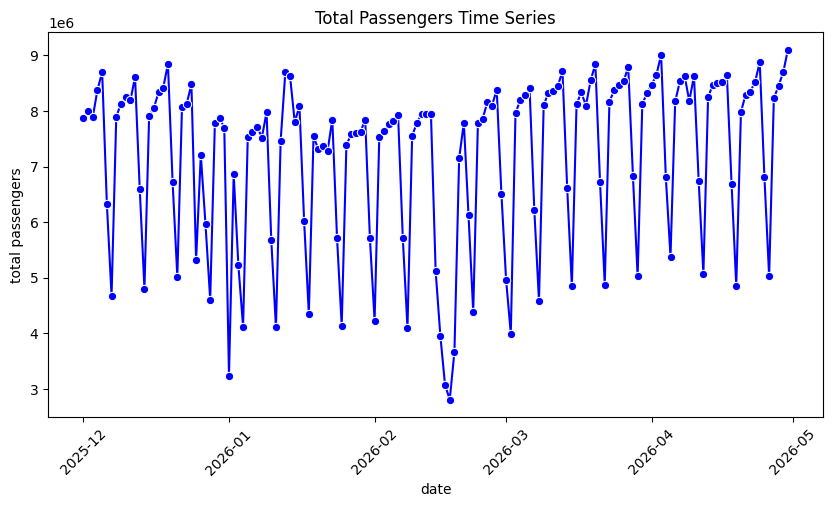

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

df_all['사용일자'] = pd.to_datetime(df_all['사용일자'].astype(str), format='mixed')
grouped1 = df_all.groupby('사용일자')['승차총승객수'].sum()
df_daily = grouped1.reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x="사용일자", y="승차총승객수", data=df_daily, color="blue", marker="o")
plt.xlabel("date")
plt.ylabel("total passengers")
plt.title("Total Passengers Time Series")
plt.xticks(rotation=45)
plt.show()